<a href="https://colab.research.google.com/github/SKS1401/MLProject-DiabetesPrediction-RandomForest/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Diabetes Prediction(Part 1)

###Loading the dataset

In [ ]:
import pandas as pd
dataset=pd.read_csv("/content/drive/MyDrive/NBICT LAB PDSML-B-8/4.Diabetes Prediction/diabetes.csv")
dataset.shape

(768, 9)

In [ ]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


###Exploratory Data Analysis(Creating Heatmap)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

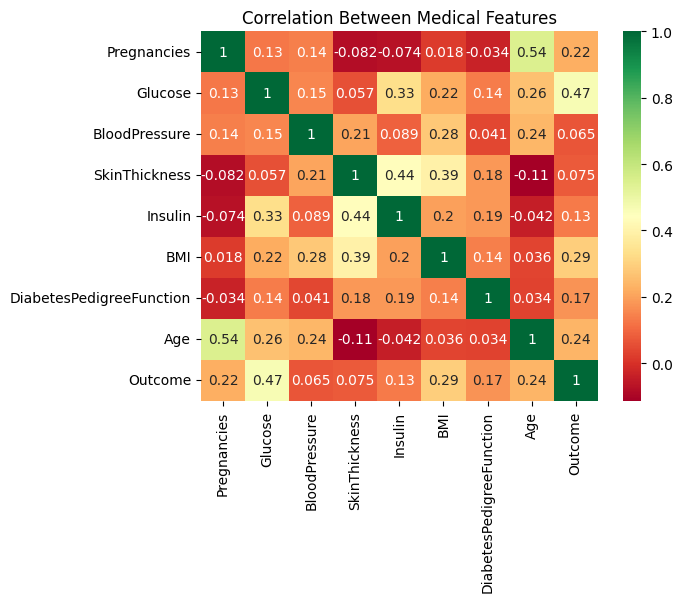

In [ ]:
correlation_matrix=dataset.corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix,annot=True,cmap='RdYlGn')
plt.title("Correlation Between Medical Features")
plt.show()

###Data Preprocessing

In [ ]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
import numpy as np
cols_to_fix=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
dataset[cols_to_fix]=dataset[cols_to_fix].replace(0,np.nan)
dataset.fillna(dataset.median(), inplace=True)

##Diabetes Prediction(Part 2)

###Creating a matrix of the features and the dependent variable vector

In [ ]:
X=dataset.drop('Outcome',axis=1)
y=dataset['Outcome']
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [ ]:
y.value_counts()

,count
Outcome,
0,500
1,268


###Splitting the dataset into the training set and the test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0,stratify=y)

In [ ]:
X_train.shape

(614, 8)

In [ ]:
X_test.shape

(154, 8)

###Feature Scaling

In [ ]:
#In this dataset, pregnancy column has much lower  numerical value than Glucose,Insulin etc column. So to eliminate this big difference of their value ,we need to scale them
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


##Training the model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=100,random_state=42)
classifier.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

##Predicting the test set results


In [ ]:
y_pred=classifier.predict(X_test)
print(y_pred)

[0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 1 1 0 1
 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0
 1 0 0 1 0 0]


##Model evaluation

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[89 11]
 [22 32]]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
acc_score=accuracy_score(y_test,y_pred)
print(acc_score)

0.7857142857142857


###Predicting for a new patient

In [ ]:
#For example we have a patient who has ----
#Pregnencies: 2, Glucose:120 , BP: 70 , SkinThickness : 30 , Insulin: 80, BMI: 25.6, DP: 0.5, Age: 32
#Now we want to predict whether this patient has diabetes or not
new_data=np.array([[2,120,70,30,80,25.6,0.5,32]])
new_data_scaled=scaler.transform(new_data)
prediction=classifier.predict(new_data_scaled)
if prediction[0]==1:
  print("The model predicts that the patient has diabetes.Please Consult a Doctor!")
else:
  print("The model predicts that the patient doesnot have diabetes!")

The model predicts that the patient doesnot have diabetes!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


###Selecting the most significant features


####Using Pearson Correlation Coefficient

In [ ]:
dataset.corr()['Outcome'].sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


####Identifying Important Factors in Random Forest

In [ ]:
importances=classifier.feature_importances_
feature_names=X.columns
feature_importance_df=pd.DataFrame({'Features':feature_names,'Importances':importances}).sort_values(ascending=False,by='Importances')
print(feature_importance_df)


                   Features  Importances
1                   Glucose     0.249633
5                       BMI     0.162431
7                       Age     0.135783
6  DiabetesPedigreeFunction     0.127350
2             BloodPressure     0.085940
4                   Insulin     0.083751
0               Pregnancies     0.083646
3             SkinThickness     0.071466


####Creating a Barplot

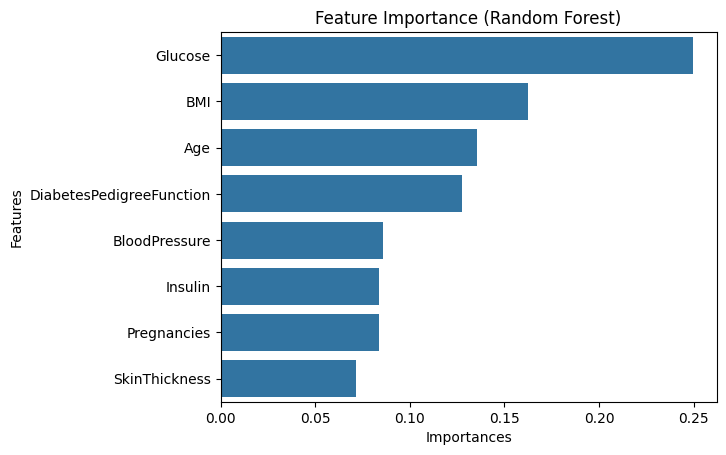

In [ ]:
sns.barplot(x='Importances',y='Features',data=feature_importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

###Sensitivity and specificity calculation

In [ ]:
tn,fp,fn,tp=cm.ravel()
print("True Negative:" ,tn)
print("False Positive:",fp)
print("False Negative:",fn)
print("True Positive:",tp)


True Negative: 89
False Positive: 11
False Negative: 22
True Positive: 32


####Calculating Sensitivity

 Sensitivity means Out Of All Patients who has Diabetes, how many the model can accurately catch

In [ ]:
sensitivity=tp/(fp+tp)
print("Sensitivity:",sensitivity)

Sensitivity: 0.7441860465116279


####Calculating Specificity

Specificity means out of all the healthy people, how many did the model correctly identifies as healthy? or identifies the patient as patient

In [ ]:
spec=tn/(tn+fp)
print("Specificity:",spec)

Specificity: 0.89
